# Day 1 — Phase 1.1: Linear Algebra
> **Date:** 2026-04-05  
> **Topic:** Vectors, Matrices, Dot Product — the math behind neural network layers

---

## 1. Vectors = Data

In AI, **every piece of data is a vector**:
- A grayscale 28×28 image → vector of **784 numbers**
- A word embedding → vector of **300 numbers**
- Network weights → **matrices of numbers**

$$\vec{x} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}$$

**Think of it like a row in a spreadsheet:** each column is one measurement (e.g. age, height, price), and one row = one data point = one vector.  
In AI, we represent *everything* as numbers in a vector so that math can operate on it.

In [1]:
import numpy as np

# A vector — e.g., 3 input features of a data sample
x = np.array([1.0, 2.0, 3.0])

print("Vector x:", x)
print("Shape:", x.shape)     # (3,) means 1D array of 3 elements
print("Length:", len(x))

Vector x: [1. 2. 3.]
Shape: (3,)
Length: 3


---
## 2. Matrix × Vector = One Neural Network Layer

The most important operation in all of deep learning:

$$\vec{y} = W\vec{x} + \vec{b}$$

- $W$ = weight matrix (what the network **learns**)
- $\vec{x}$ = input vector
- $\vec{b}$ = bias vector
- $\vec{y}$ = output of one layer

**This is literally one fully-connected layer in PyTorch (`nn.Linear`).**

**Why bias $\\vec{b}$?** It lets the neuron shift its output up or down, independent of the input — like the y-intercept in $y = mx + b$ from basic algebra.  
Without bias, every neuron output would be 0 when the input is 0, which severely limits what the network can learn.

In [3]:
# A 1-layer neural net: y = Wx + b
# Input: 3 features
x = np.array([1.0, 2.0, 3.0])

# Weight matrix: 2 neurons, each connected to 3 inputs → shape (2, 3)
W = np.array([[0.1, 0.2, 0.3],
              [0.4, 0.5, 0.6]])

# Bias: one per neuron → shape (2,)
b = np.array([0.1, -0.1])

z = W @ x  # Matrix multiply W and x → shape (2,)
print("Linear output z:", z)

# Forward pass — @ is matrix multiply in NumPy
y = W @ x + b

print("Input x:", x, "shape:", x.shape)
print("Weights W shape:", W.shape)   # (2, 3)
print("Output y:", y, "shape:", y.shape)  # (2,)

Linear output z: [1.4 3.2]
Input x: [1. 2. 3.] shape: (3,)
Weights W shape: (2, 3)
Output y: [1.5 3.1] shape: (2,)


### Deep Dive: What `W @ x` Actually Computes

`W @ x` is **matrix-vector multiplication**. Each output element is a **dot product** of one row of W with the entire input x.

Given W is (2×3) and x is (3,):

```
W       =  [[0.1, 0.2, 0.3],    x = [1.0,
             [0.4, 0.5, 0.6]]        2.0,
                                      3.0]
```

**Neuron 1** = row 0 of W · x:
```
y[0] = (0.1×1.0) + (0.2×2.0) + (0.3×3.0)
     =   0.1     +   0.4     +   0.9
     =   1.4
```

**Neuron 2** = row 1 of W · x:
```
y[1] = (0.4×1.0) + (0.5×2.0) + (0.6×3.0)
     =   0.4     +   1.0     +   1.8
     =   3.2
```

Each weight `W[i, j]` = *"how much does input feature j influence output neuron i?"*

This is why it's called **fully-connected**: every neuron sees every input.

In [4]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])
W = np.array([[0.1, 0.2, 0.3],
              [0.4, 0.5, 0.6]])
b = np.array([0.1, -0.1])

# --- Manual computation, neuron by neuron ---
print("=== Manual computation ===")
for i in range(W.shape[0]):
    terms = [f"({W[i,j]}×{x[j]})" for j in range(len(x))]
    result = np.dot(W[i], x)
    print(f"Neuron {i+1}: {' + '.join(terms)} = {result:.4f}  →  +bias({b[i]}) = {result + b[i]:.4f}")

# --- NumPy W @ x (should match exactly) ---
print("\n=== NumPy W @ x + b ===")
y = W @ x + b
print("y =", y)

# --- Verify they match ---
manual_y = np.array([np.dot(W[i], x) + b[i] for i in range(W.shape[0])])
print("\nManual == NumPy:", np.allclose(y, manual_y))

=== Manual computation ===
Neuron 1: (0.1×1.0) + (0.2×2.0) + (0.3×3.0) = 1.4000  →  +bias(0.1) = 1.5000
Neuron 2: (0.4×1.0) + (0.5×2.0) + (0.6×3.0) = 3.2000  →  +bias(-0.1) = 3.1000

=== NumPy W @ x + b ===
y = [1.5 3.1]

Manual == NumPy: True


### Exercise 1 — Dimension Check
**Questions & Answers:**

1. `W` is (2×3) and `x` is (3,) — why does this work dimensionally?
   > ✅ W has 3 **columns** and x has 3 **elements** — inner dimensions match. Rule: `(m×n) @ (n,)` → `(m,)`. Output y is shape (2,).

2. Change `W` to shape (4×3) — what happens to `y`?
   > ✅ Still works. y becomes shape **(4,)** — one output per neuron, now 4 neurons instead of 2.

3. What does the number of **rows** in `W` represent? The number of **columns**?
   > - **Rows** = number of **output neurons** (each row is one neuron's full weight vector)
   > - **Columns** = number of **input features** (how many inputs each neuron receives)
   >
   > PyTorch: `nn.Linear(in_features=3, out_features=2)` → W shape is **(out_features × in_features) = (2×3)**

In [5]:
# Exercise 1: Try a 4-neuron layer
W4 = np.random.randn(4, 3)   # 4 neurons, 3 inputs
b4 = np.zeros(4)

y4 = W4 @ x + b4
print("W4 shape:", W4.shape)
print("y4:", y4, "shape:", y4.shape)

# Rule: (n_out x n_in) @ (n_in,) = (n_out,)
# rows of W = number of output neurons
# cols of W = number of input features

W4 shape: (4, 3)
y4: [-0.25753796  2.83239276 -4.14336263 -2.75124925] shape: (4,)


---
## 3. Stacking Layers = Matrix Chain

A 2-layer network:
$$\vec{h} = W_1\vec{x} + \vec{b}_1 \quad \text{(hidden layer)}$$
$$\vec{y} = W_2\vec{h} + \vec{b}_2 \quad \text{(output layer)}$$

Each layer **transforms** the vector into a new space. The shapes must be compatible.

In [6]:
# 2-layer network: input(3) → hidden(4) → output(2)
x = np.array([1.0, 2.0, 3.0])     # input: 3 features

W1 = np.random.randn(4, 3)         # layer 1: (4, 3)
b1 = np.zeros(4)

W2 = np.random.randn(2, 4)         # layer 2: (2, 4)
b2 = np.zeros(2)

h = W1 @ x + b1     # hidden: shape (4,)
y = W2 @ h + b2     # output: shape (2,)

print("Input:", x.shape, "→ Hidden:", h.shape, "→ Output:", y.shape)

Input: (3,) → Hidden: (4,) → Output: (2,)


---
## 4. Dot Product = Similarity

$$\vec{a} \cdot \vec{b} = \sum_i a_i b_i = |\vec{a}||\vec{b}|\cos\theta$$

Used in:
- **Attention** (how similar is query $q$ to key $k$?)
- **Cosine similarity** for comparing word embeddings
- When $\cos\theta = 1$: vectors are identical direction (maximum similarity)
- When $\cos\theta = 0$: vectors are perpendicular (no similarity)

In [ ]:
a = np.array([1.0, 0.0, 0.0])   # unit vector along x-axis
b = np.array([1.0, 0.0, 0.0])   # identical
c = np.array([0.0, 1.0, 0.0])   # perpendicular
d = np.array([0.8, 0.6, 0.0])   # similar but not identical

def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print("a · a (identical):", cosine_similarity(a, b))   # 1.0
print("a · c (perpendicular):", cosine_similarity(a, c))  # 0.0
print("a · d (similar):", cosine_similarity(a, d))   # ~0.8

---
## 5. Visualize: What a Matrix Transformation Does

A matrix **rotates, scales, and projects** vectors into a new space.  
That is literally what each neural network layer does to your data.

Matplotlib is building the font cache; this may take a moment.
/lhome/giatran/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


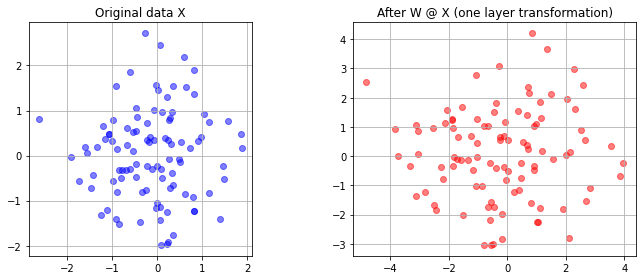

Notice: the data cloud is stretched and rotated — this is what a layer does!


In [7]:
import matplotlib.pyplot as plt

# Generate 100 random 2D points (a "dataset")
np.random.seed(42)
X = np.random.randn(100, 2)   # 100 samples, 2 features

# A transformation matrix (rotation + scale)
W = np.array([[2.0, 0.5],
              [-0.5, 1.5]])

# Apply transformation: each row of X is one sample
X_transformed = (W @ X.T).T   # shape stays (100, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:, 0], X[:, 1], alpha=0.5, color='blue')
ax1.set_title('Original data X')
ax1.set_aspect('equal')
ax1.grid(True)

ax2.scatter(X_transformed[:, 0], X_transformed[:, 1], alpha=0.5, color='red')
ax2.set_title('After W @ X (one layer transformation)')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()
print("Notice: the data cloud is stretched and rotated — this is what a layer does!")

---
## Summary

| Concept | Math | AI Usage |
|---|---|---|
| Vector | $\vec{x} \in \mathbb{R}^n$ | Data sample, embedding, feature vector |
| Matrix-vector multiply | $W\vec{x} + \vec{b}$ | One fully-connected layer |
| Stacking layers | $W_2(W_1\vec{x}+b_1)+b_2$ | Deep network forward pass |
| Dot product / cosine | $\vec{a}\cdot\vec{b}$ | Attention, similarity search |
| Matrix transformation | $W\vec{x}$ | Feature rotation/scaling per layer |

---
## Next: Day 2 — Eigenvalues, SVD, and PCA
These explain *why* neural networks can compress information and find structure in data.

---
## My Notes
> *(Write your own observations, questions, and breakthroughs here)*